# CNN Training for Glucose Alarm Detection

This notebook trains a convolutional neural network to detect glucose alarm sounds from short audio windows.

**Input**: Windowed audio dataset from `prepare_dataset.ipynb`

**Output**: 
- Trained CNN model
- Training metrics and plots
- Evaluation results

**Goal**: Proof-of-learnability - can a CNN distinguish glucose alarm windows from non-alarm windows?

## 1. Imports & Configuration

In [1]:
# Imports
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Audio parameters
SAMPLE_RATE = 16000          # Hz
WINDOW_LENGTH = 1.0          # seconds

# Spectrogram parameters
N_MELS = 64                  # Number of mel bands
N_FFT = 1024                 # FFT size
HOP_LENGTH = 256             # Hop length for spectrogram

# Training parameters
BATCH_SIZE = 32
NUM_EPOCHS = 20
LEARNING_RATE = 0.001

# Paths
DATASET_DIR = Path('dataset')
TRAIN_DIR = DATASET_DIR / 'train'
VAL_DIR = DATASET_DIR / 'val'
METADATA_FILE = DATASET_DIR / 'dataset_metadata.csv'
MODEL_SAVE_PATH = 'glucose_alarm_cnn.pth'

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Configuration:")
print(f"  Sample rate: {SAMPLE_RATE} Hz")
print(f"  Window length: {WINDOW_LENGTH}s")
print(f"  Mel bands: {N_MELS}")
print(f"  FFT size: {N_FFT}")
print(f"  Hop length: {HOP_LENGTH}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Device: {DEVICE}")

Configuration:
  Sample rate: 16000 Hz
  Window length: 1.0s
  Mel bands: 64
  FFT size: 1024
  Hop length: 256
  Batch size: 32
  Epochs: 20
  Learning rate: 0.001
  Device: cpu


## 2. Dataset Loading

Custom PyTorch Dataset that:
1. Loads WAV files from disk
2. Computes log-mel spectrograms
3. Returns tensors shaped (1, n_mels, time_frames)
4. Returns binary labels

In [3]:
class AudioWindowDataset(Dataset):
    """
    PyTorch Dataset for audio windows.
    
    Loads WAV files and computes log-mel spectrograms on-the-fly.
    """
    
    def __init__(self, metadata_df, audio_dir, sample_rate=16000, 
                 n_mels=64, n_fft=1024, hop_length=256):
        """
        Parameters:
        -----------
        metadata_df : pd.DataFrame
            DataFrame with 'filename' and 'label' columns
        audio_dir : Path
            Directory containing WAV files
        sample_rate : int
            Target sample rate
        n_mels : int
            Number of mel bands
        n_fft : int
            FFT size
        hop_length : int
            Hop length for STFT
        """
        self.metadata = metadata_df.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.sample_rate = sample_rate
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
        
        # Verify files exist
        self._verify_files()
    
    def _verify_files(self):
        """Check that all files in metadata exist on disk."""
        missing = []
        for filename in self.metadata['filename']:
            filepath = self.audio_dir / filename
            if not filepath.exists():
                missing.append(filename)
        
        if missing:
            raise FileNotFoundError(f"Missing {len(missing)} files: {missing[:5]}...")
    
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        """
        Load audio window and compute log-mel spectrogram.
        
        Returns:
        --------
        spectrogram : torch.Tensor
            Shape (1, n_mels, time_frames)
        label : torch.Tensor
            Binary label (0 or 1)
        """
        # Get metadata
        row = self.metadata.iloc[idx]
        filename = row['filename']
        label = row['label']
        
        # Load audio
        filepath = self.audio_dir / filename
        audio, sr = librosa.load(filepath, sr=self.sample_rate, mono=True)
        
        # Compute mel spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=audio,
            sr=self.sample_rate,
            n_mels=self.n_mels,
            n_fft=self.n_fft,
            hop_length=self.hop_length
        )
        
        # Convert to log scale (dB)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Convert to tensor and add channel dimension
        # Shape: (1, n_mels, time_frames)
        spectrogram = torch.FloatTensor(log_mel_spec).unsqueeze(0)
        
        # Convert label to tensor
        label = torch.FloatTensor([label])
        
        return spectrogram, label

## 3. Data Loaders

Create training and validation data loaders.

In [4]:
# Load metadata
print("Loading metadata...")
metadata = pd.read_csv(METADATA_FILE)

print(f"Total samples: {len(metadata)}")
print(f"\nSplit distribution:")
print(metadata['split'].value_counts())
print(f"\nLabel distribution:")
print(metadata['label'].value_counts())

Loading metadata...
Total samples: 2868

Split distribution:
split
train    1434
val      1434
Name: count, dtype: int64

Label distribution:
label
1    1434
0    1434
Name: count, dtype: int64


In [5]:
# Split metadata by train/val
train_metadata = metadata[metadata['split'] == 'train'].copy()
val_metadata = metadata[metadata['split'] == 'val'].copy()

print(f"Training samples: {len(train_metadata)}")
print(f"  Class 0: {(train_metadata['label'] == 0).sum()}")
print(f"  Class 1: {(train_metadata['label'] == 1).sum()}")

print(f"\nValidation samples: {len(val_metadata)}")
print(f"  Class 0: {(val_metadata['label'] == 0).sum()}")
print(f"  Class 1: {(val_metadata['label'] == 1).sum()}")

Training samples: 1434
  Class 0: 717
  Class 1: 717

Validation samples: 1434
  Class 0: 717
  Class 1: 717


In [8]:
# Create datasets
print("\nCreating datasets...")

train_dataset = AudioWindowDataset(
    metadata_df=train_metadata,
    audio_dir=TRAIN_DIR,
    sample_rate=SAMPLE_RATE,
    n_mels=N_MELS,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH
)

val_dataset = AudioWindowDataset(
    metadata_df=val_metadata,
    audio_dir=VAL_DIR,
    sample_rate=SAMPLE_RATE,
    n_mels=N_MELS,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH
)

print(f"✓ Train dataset: {len(train_dataset)} samples")
print(f"✓ Val dataset: {len(val_dataset)} samples")


Creating datasets...
✓ Train dataset: 1434 samples
✓ Val dataset: 1434 samples


In [7]:
# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0  # Set to 0 for compatibility, increase for faster loading
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"\nData loaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")


Data loaders created:
  Train batches: 45
  Val batches: 45


In [9]:
# Test loading a batch
print("\nTesting data loading...")
sample_batch, sample_labels = next(iter(train_loader))
print(f"  Batch shape: {sample_batch.shape}")
print(f"  Labels shape: {sample_labels.shape}")
print(f"  Spectrogram range: [{sample_batch.min():.2f}, {sample_batch.max():.2f}]")
print(f"  Labels in batch: {sample_labels.squeeze().tolist()[:8]}...")


Testing data loading...
  Batch shape: torch.Size([32, 1, 64, 63])
  Labels shape: torch.Size([32, 1])
  Spectrogram range: [-80.00, 0.00]
  Labels in batch: [0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0]...


## 4. CNN Model

Define a small CNN for binary classification:
- 3 convolutional blocks (Conv2D → ReLU → MaxPool)
- Global average pooling
- Fully connected layer
- Single output logit

In [11]:
class GlucoseAlarmCNN(nn.Module):
    """
    Convolutional Neural Network for glucose alarm detection.
    
    Input: (batch_size, 1, n_mels, time_frames)
    Output: (batch_size, 1) - single logit for binary classification
    """
    
    def __init__(self, n_mels=64):
        super(GlucoseAlarmCNN, self).__init__()
        
        # Convolutional block 1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Convolutional block 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Convolutional block 3
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Global average pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully connected layer
        self.fc = nn.Linear(128, 1)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        """
        Forward pass.
        
        Parameters:
        -----------
        x : torch.Tensor
            Input tensor of shape (batch_size, 1, n_mels, time_frames)
        
        Returns:
        --------
        torch.Tensor
            Output logits of shape (batch_size, 1)
        """
        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)
        
        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)
        
        # Block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool3(x)
        
        # Global average pooling
        x = self.global_avg_pool(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Dropout
        x = self.dropout(x)
        
        # Fully connected
        x = self.fc(x)
        
        return x

In [12]:
# Initialize model
model = GlucoseAlarmCNN(n_mels=N_MELS).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model architecture:
GlucoseAlarmCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_avg_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Total parameters: 93,249
Trainable paramet

In [13]:
# Test forward pass
print("\nTesting forward pass...")
with torch.no_grad():
    test_input = sample_batch.to(DEVICE)
    test_output = model(test_input)
    print(f"  Input shape: {test_input.shape}")
    print(f"  Output shape: {test_output.shape}")
    print(f"  Output range: [{test_output.min():.2f}, {test_output.max():.2f}]")


Testing forward pass...
  Input shape: torch.Size([32, 1, 64, 63])
  Output shape: torch.Size([32, 1])
  Output range: [-1.33, 0.55]


## 5. Training Loop

Train the model using:
- Binary cross-entropy with logits loss
- Adam optimizer
- Track training and validation metrics

In [14]:
# Loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Training configuration:")
print(f"  Loss function: Binary Cross-Entropy with Logits")
print(f"  Optimizer: Adam")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")

Training configuration:
  Loss function: Binary Cross-Entropy with Logits
  Optimizer: Adam
  Learning rate: 0.001
  Epochs: 20


In [15]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train for one epoch.
    
    Returns:
    --------
    float
        Average training loss
    """
    model.train()
    running_loss = 0.0
    
    for spectrograms, labels in train_loader:
        # Move to device
        spectrograms = spectrograms.to(device)
        labels = labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(spectrograms)
        
        # Compute loss
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    return avg_loss


def validate_epoch(model, val_loader, criterion, device):
    """
    Validate for one epoch.
    
    Returns:
    --------
    tuple
        (average validation loss, accuracy)
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for spectrograms, labels in val_loader:
            # Move to device
            spectrograms = spectrograms.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(spectrograms)
            
            # Compute loss
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            # Compute accuracy
            predictions = torch.sigmoid(outputs) > 0.5
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    
    avg_loss = running_loss / len(val_loader)
    accuracy = correct / total
    
    return avg_loss, accuracy

In [16]:
# Training loop
print("\nStarting training...\n")
print("="*70)

# Track metrics
train_losses = []
val_losses = []
val_accuracies = []

best_val_loss = float('inf')
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    train_losses.append(train_loss)
    
    # Validate
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, DEVICE)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    # Print progress
    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"  → Best model saved (val_loss: {val_loss:.4f})")

print("="*70)
print(f"\nTraining complete!")
print(f"Best model from epoch {best_epoch} with val_loss: {best_val_loss:.4f}")
print(f"Model saved to: {MODEL_SAVE_PATH}")


Starting training...

Epoch [ 1/20] | Train Loss: 0.4438 | Val Loss: 1.1592 | Val Acc: 0.5139
  → Best model saved (val_loss: 1.1592)
Epoch [ 2/20] | Train Loss: 0.3018 | Val Loss: 1.1255 | Val Acc: 0.5084
  → Best model saved (val_loss: 1.1255)
Epoch [ 3/20] | Train Loss: 0.2767 | Val Loss: 0.8867 | Val Acc: 0.6179
  → Best model saved (val_loss: 0.8867)
Epoch [ 4/20] | Train Loss: 0.2585 | Val Loss: 1.0670 | Val Acc: 0.5049
Epoch [ 5/20] | Train Loss: 0.2467 | Val Loss: 0.9674 | Val Acc: 0.5195
Epoch [ 6/20] | Train Loss: 0.2194 | Val Loss: 1.0828 | Val Acc: 0.5384
Epoch [ 7/20] | Train Loss: 0.2255 | Val Loss: 1.3055 | Val Acc: 0.5167
Epoch [ 8/20] | Train Loss: 0.2233 | Val Loss: 1.2454 | Val Acc: 0.5153
Epoch [ 9/20] | Train Loss: 0.2036 | Val Loss: 1.1310 | Val Acc: 0.5244
Epoch [10/20] | Train Loss: 0.1967 | Val Loss: 1.2071 | Val Acc: 0.5202
Epoch [11/20] | Train Loss: 0.1976 | Val Loss: 1.0340 | Val Acc: 0.5635
Epoch [12/20] | Train Loss: 0.1877 | Val Loss: 1.1282 | Val Acc: 

## 6. Evaluation

Evaluate the trained model on the validation set.

In [17]:
# Load best model
print("Loading best model...")
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()
print("✓ Model loaded")

Loading best model...
✓ Model loaded


In [18]:
# Get predictions on validation set
print("\nComputing predictions on validation set...")

all_predictions = []
all_labels = []
all_probabilities = []

with torch.no_grad():
    for spectrograms, labels in val_loader:
        spectrograms = spectrograms.to(DEVICE)
        
        # Get predictions
        outputs = model(spectrograms)
        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities > 0.5).float()
        
        # Store results
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

# Convert to numpy arrays
all_predictions = np.array(all_predictions).flatten()
all_labels = np.array(all_labels).flatten()
all_probabilities = np.array(all_probabilities).flatten()

print(f"✓ Predictions computed for {len(all_labels)} samples")


Computing predictions on validation set...
✓ Predictions computed for 1434 samples


In [19]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

print("\nConfusion Matrix:")
print("                Predicted")
print("              0         1")
print(f"Actual 0  {cm[0,0]:5d}   {cm[0,1]:5d}")
print(f"       1  {cm[1,0]:5d}   {cm[1,1]:5d}")

# Compute metrics
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_predictions, average='binary'
)

accuracy = (all_predictions == all_labels).mean()

print("\nClassification Metrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")


Confusion Matrix:
                Predicted
              0         1
Actual 0    411     306
       1    242     475

Classification Metrics:
  Accuracy:  0.6179
  Precision: 0.6082
  Recall:    0.6625
  F1 Score:  0.6342


In [20]:
# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(
    all_labels, 
    all_predictions, 
    target_names=['No Alarm (0)', 'Glucose Alarm (1)']
))


Detailed Classification Report:
                   precision    recall  f1-score   support

     No Alarm (0)       0.63      0.57      0.60       717
Glucose Alarm (1)       0.61      0.66      0.63       717

         accuracy                           0.62      1434
        macro avg       0.62      0.62      0.62      1434
     weighted avg       0.62      0.62      0.62      1434



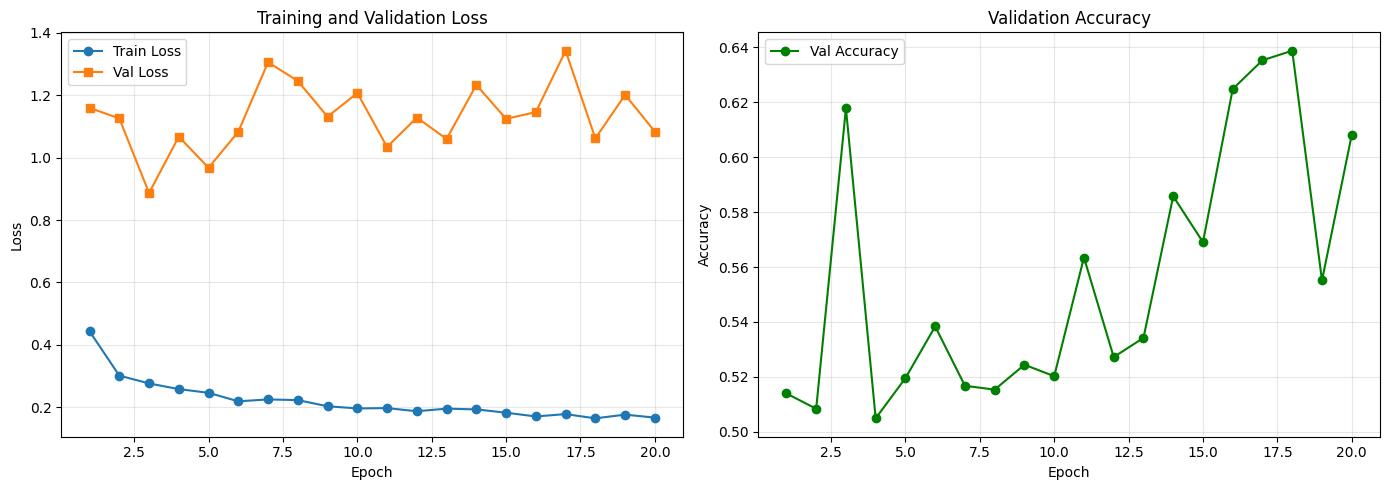


Final training loss: 0.1672
Final validation loss: 1.0832
Final validation accuracy: 0.6081


In [21]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(range(1, NUM_EPOCHS + 1), train_losses, label='Train Loss', marker='o')
axes[0].plot(range(1, NUM_EPOCHS + 1), val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(range(1, NUM_EPOCHS + 1), val_accuracies, label='Val Accuracy', marker='o', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal training loss: {train_losses[-1]:.4f}")
print(f"Final validation loss: {val_losses[-1]:.4f}")
print(f"Final validation accuracy: {val_accuracies[-1]:.4f}")

## 7. Sanity Checks

Visualize predictions on random validation samples to verify the model is learning meaningful patterns.

In [22]:
# Select random validation samples
np.random.seed(42)
num_samples = 6
random_indices = np.random.choice(len(val_dataset), num_samples, replace=False)

print(f"Randomly selected {num_samples} validation samples for inspection:\n")

Randomly selected 6 validation samples for inspection:



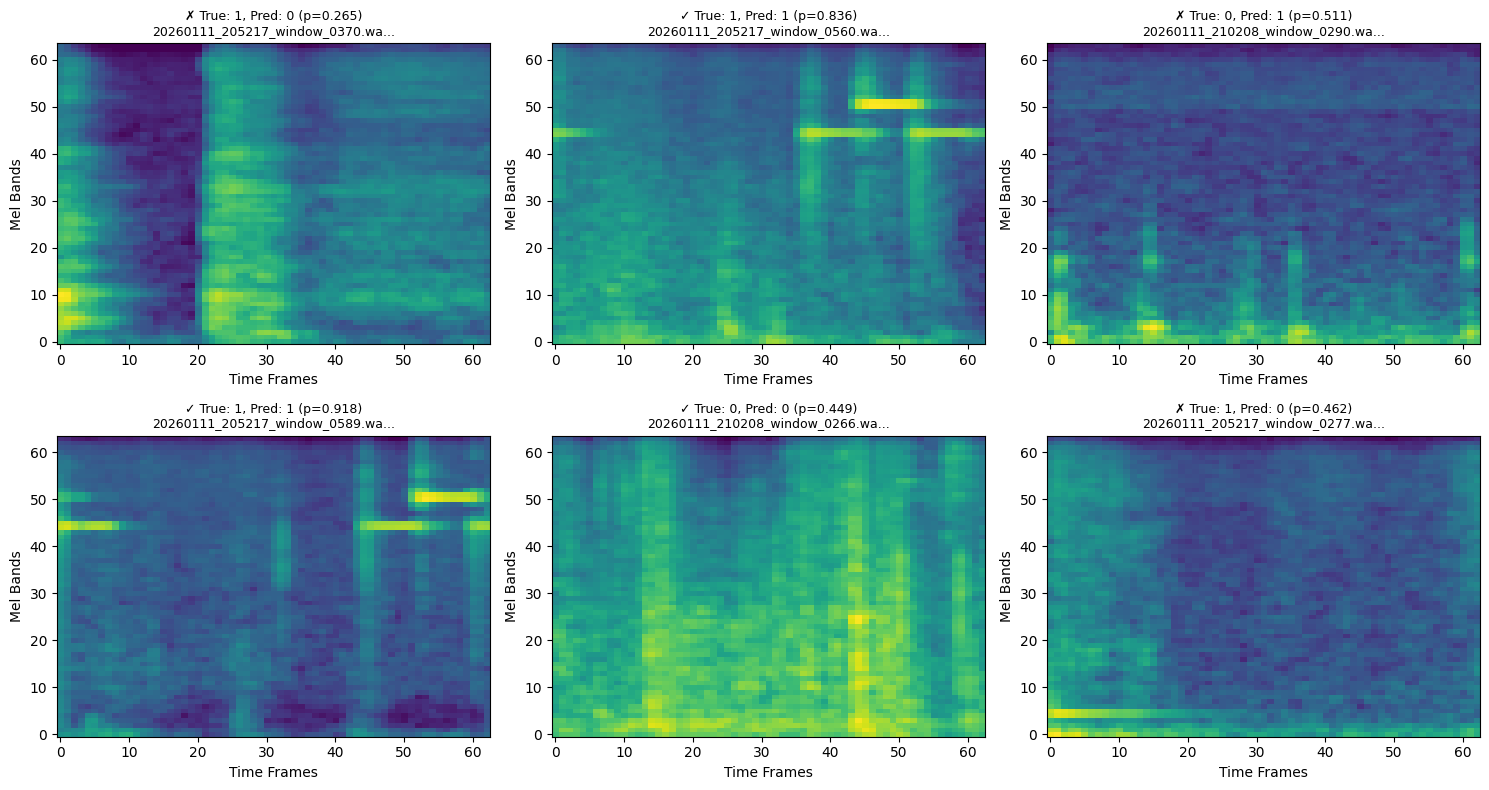

In [23]:
# Visualize samples with predictions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

model.eval()
with torch.no_grad():
    for i, idx in enumerate(random_indices):
        # Get sample
        spectrogram, label = val_dataset[idx]
        
        # Get prediction
        spec_input = spectrogram.unsqueeze(0).to(DEVICE)
        output = model(spec_input)
        probability = torch.sigmoid(output).item()
        prediction = 1 if probability > 0.5 else 0
        
        # Get metadata
        sample_metadata = val_metadata.iloc[idx]
        filename = sample_metadata['filename']
        
        # Plot spectrogram
        spec_np = spectrogram.squeeze().numpy()
        axes[i].imshow(spec_np, aspect='auto', origin='lower', cmap='viridis')
        axes[i].set_xlabel('Time Frames')
        axes[i].set_ylabel('Mel Bands')
        
        # Title with prediction info
        true_label = int(label.item())
        correct = '✓' if prediction == true_label else '✗'
        
        axes[i].set_title(
            f"{correct} True: {true_label}, Pred: {prediction} (p={probability:.3f})\n"
            f"{filename[:30]}...",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [24]:
# Print detailed information for each sample
print("\nDetailed Sample Information:\n")
print("="*80)

model.eval()
with torch.no_grad():
    for i, idx in enumerate(random_indices):
        # Get sample
        spectrogram, label = val_dataset[idx]
        
        # Get prediction
        spec_input = spectrogram.unsqueeze(0).to(DEVICE)
        output = model(spec_input)
        probability = torch.sigmoid(output).item()
        prediction = 1 if probability > 0.5 else 0
        
        # Get metadata
        sample_metadata = val_metadata.iloc[idx]
        
        # Print info
        true_label = int(label.item())
        correct = '✓ CORRECT' if prediction == true_label else '✗ INCORRECT'
        
        print(f"Sample {i+1}:")
        print(f"  Filename:        {sample_metadata['filename']}")
        print(f"  Session ID:      {sample_metadata['session_id']}")
        print(f"  Window Index:    {sample_metadata['window_index']}")
        print(f"  Context:         {sample_metadata['context']}")
        print(f"  Ground Truth:    {true_label} ({'Glucose Alarm' if true_label == 1 else 'No Alarm'})")
        print(f"  Prediction:      {prediction} ({'Glucose Alarm' if prediction == 1 else 'No Alarm'})")
        print(f"  Probability:     {probability:.4f}")
        print(f"  Result:          {correct}")
        print("-"*80)

print("="*80)


Detailed Sample Information:

Sample 1:
  Filename:        20260111_205217_window_0370.wav
  Session ID:      20260111_205217
  Window Index:    370
  Context:         background_noise
  Ground Truth:    1 (Glucose Alarm)
  Prediction:      0 (No Alarm)
  Probability:     0.2646
  Result:          ✗ INCORRECT
--------------------------------------------------------------------------------
Sample 2:
  Filename:        20260111_205217_window_0560.wav
  Session ID:      20260111_205217
  Window Index:    560
  Context:         background_noise
  Ground Truth:    1 (Glucose Alarm)
  Prediction:      1 (Glucose Alarm)
  Probability:     0.8361
  Result:          ✓ CORRECT
--------------------------------------------------------------------------------
Sample 3:
  Filename:        20260111_210208_window_0290.wav
  Session ID:      20260111_210208
  Window Index:    290
  Context:         background_noise
  Ground Truth:    0 (No Alarm)
  Prediction:      1 (Glucose Alarm)
  Probability:    

## Summary

### Model Performance

This notebook demonstrates proof-of-learnability:
- The CNN can learn to distinguish glucose alarm windows from non-alarm windows
- Performance metrics indicate whether the model generalizes to unseen sessions

### Key Observations

1. **Training curves**: Check for overfitting (train loss << val loss)
2. **Confusion matrix**: Identify which class is harder to predict
3. **Sample predictions**: Verify the model is learning meaningful patterns

### Limitations

- This is a window-level classifier (no temporal aggregation)
- No post-processing or thresholding applied
- Limited to the sessions in the dataset

### Next Steps

1. **Collect more data**: Record more sessions for better generalization
2. **Data augmentation**: Add time/frequency masking, noise injection
3. **Architecture tuning**: Experiment with different CNN architectures
4. **Temporal modeling**: Add LSTM or attention for sequence modeling
5. **Deployment**: Implement real-time inference with sliding windows

In [ ]:
# Save final metrics
metrics_summary = {
    'final_train_loss': train_losses[-1],
    'final_val_loss': val_losses[-1],
    'final_val_accuracy': val_accuracies[-1],
    'best_val_loss': best_val_loss,
    'best_epoch': best_epoch,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1
}

print("\nFinal Metrics Summary:")
print("="*50)
for key, value in metrics_summary.items():
    print(f"{key:25s}: {value:.4f}")
print("="*50)